In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from pathlib import Path

SCHED_DIR  = Path('outputs/scheduler_outputs')
CPS        = 100_000_000
DURATION_S = 10.0

# ── hardware order ────────────────────────────────────────────────────────────
HOMO_HW_ORDER   = ['mono128', 'comp4x64', 'comp16x32', 'comp64x16']
HETERO_HW_ORDER = ['hetero1', 'hetero2', 'hetero3']
ALL_HW_ORDER    = HOMO_HW_ORDER + HETERO_HW_ORDER
HW_LABELS = {
    'mono128':   'SA128',         'comp4x64':  'SA64',
    'comp16x32': 'SA32',         'comp64x16': 'SA16',
    'hetero1':   'Hetero1',          'hetero2':   'Hetero2',
    'hetero3':   'Hetero3',
}
HW_ORDER = HOMO_HW_ORDER  # backward compat

# ── alloc parsing (longest-match substring) ───────────────────────────────────
HOMO_ALLOC_VALUES = {'greedy', 'fair', 'deadline_fold'}
HETERO_WAFF_TAGS  = ['hetero_W25', 'hetero_W50', 'hetero_W75']
ALL_ALLOC_VALUES  = HOMO_ALLOC_VALUES | set(HETERO_WAFF_TAGS)
ALLOC_VALUES = {'greedy', 'fair'}  # kept for reference

def _parse_alloc(stem: str) -> str:
    for tag in sorted(ALL_ALLOC_VALUES, key=len, reverse=True):
        if tag in stem:
            return tag
    return 'model'

# ── LP key constants ──────────────────────────────────────────────────────────
# deadline changed to red so orange is exclusively for hetero bars
LP_KEYS   = ['fifo_greedy', 'lpt_greedy', 'deadline_greedy']
LP_LABELS = {'fifo_greedy': 'FIFO', 'lpt_greedy': 'LPT', 'deadline_greedy': 'Deadline'}
LP_COLORS = {'fifo_greedy': '#4878d0', 'lpt_greedy': '#6acc65', 'deadline_greedy': '#ff7f0e'}

HETERO_LP_KEYS   = ['deadline_hetero_W25', 'deadline_hetero_W50', 'deadline_hetero_W75']
HETERO_LP_LABELS = {
    'deadline_hetero_W25': 'Hetero W_aff=0.25',
    'deadline_hetero_W50': 'Hetero W_aff=0.50',
    'deadline_hetero_W75': 'Hetero W_aff=0.75',
}
HETERO_COLOR   = '#ff7f0e'          # all hetero bars share this orange
HETERO_HATCHES = ['.', '//', '*']   # dots, diagonal lines, stars
HETERO_EDGE    = '#555555'          # hatch line color

THROUGHPUT_MODELS = ['emformer', 'mobilellm_125m']
LATENCY_MODELS    = ['hand_pose', 'eyecod', 'key_res15', 'tcn', 'd2go', 'deit_small']

# ── load summary CSVs ─────────────────────────────────────────────────────────
summaries = []
for p in sorted(SCHED_DIR.glob('xrbench_*_summary.csv')):
    alloc = _parse_alloc(p.stem)
    if alloc == 'model':
        continue
    df = pd.read_csv(p)
    df['alloc'] = alloc
    summaries.append(df)

sched_all = pd.concat(summaries, ignore_index=True)
sched_all = sched_all[sched_all['scenario'] == 'xrbench_8model'].copy()
sched_all['lp_key'] = (
    sched_all['policy'].str.replace('deadline_task_aware', 'deadline', regex=False)
    + '_' + sched_all['alloc']
)

# ── load trace CSVs ───────────────────────────────────────────────────────────
POL_ORDER = ['fifo', 'lpt', 'deadline_task_aware']
traces = []
for path in sorted(SCHED_DIR.glob('*8model*_trace.csv')):
    alloc = _parse_alloc(path.stem)
    if alloc == 'model':
        continue
    hw  = next((h for h in ALL_HW_ORDER if h in path.stem), None)
    pol = next((p for p in POL_ORDER if p in path.stem), None)
    if hw is None or pol is None:
        continue
    lp_key = f"{pol.replace('deadline_task_aware', 'deadline')}_{alloc}"
    df = pd.read_csv(path)
    df['hardware'] = hw
    df['lp_key']   = lp_key
    if 'mode' not in df.columns:
        df['mode'] = df['model'].map(
            lambda m: 'throughput' if m in THROUGHPUT_MODELS else 'latency')
    traces.append(df)

trace = pd.concat(traces, ignore_index=True)

# ── helper: filter trace to a hw-set × lp-set ────────────────────────────────
def _sub(hw_list, lp_list):
    return trace[trace['hardware'].isin(hw_list) & trace['lp_key'].isin(lp_list)].copy()

def _lat_stats(t, hw_order, lp_list):
    lat   = t[t['mode'] == 'latency'].copy()
    hit   = lat[lat['deadline_miss'] == 0].copy()
    hit['response_ms'] = hit['response_cycles'] / CPS * 1000
    resp  = hit.groupby(['hardware','lp_key']).agg(mean_resp_ms=('response_ms','mean')).reset_index()
    miss  = lat.groupby(['hardware','lp_key']).agg(miss_pct=('deadline_miss', lambda x: x.mean()*100)).reset_index()
    merged = resp.merge(miss, on=['hardware','lp_key'])
    lat_p  = merged.pivot(index='hardware', columns='lp_key', values='mean_resp_ms').reindex(hw_order)
    miss_p = merged.pivot(index='hardware', columns='lp_key', values='miss_pct').reindex(hw_order)
    return lat_p, miss_p, lat, hit

def _tp_counts(t, hw_order, lp_list):
    tp = t[(t['mode']=='throughput') & (t['deadline_miss']==0)].copy()
    cnt = tp.groupby(['hardware','lp_key','model']).size().reset_index(name='completions')
    cnt['throughput_rps'] = cnt['completions'] / DURATION_S
    return cnt

def _util_pivot(hw_order, lp_list):
    sub = sched_all[sched_all['hardware'].isin(hw_order) & sched_all['lp_key'].isin(lp_list)]
    return sub.pivot_table(index='hardware', columns='lp_key',
                           values='pe_utilization', aggfunc='first').reindex(hw_order)

# ── homo stats ────────────────────────────────────────────────────────────────
trace_homo = _sub(HOMO_HW_ORDER, LP_KEYS)
lat_piv, miss_piv, lat_all, lat_hit = _lat_stats(trace_homo, HW_ORDER, LP_KEYS)
tp_counts  = _tp_counts(trace_homo, HW_ORDER, LP_KEYS)
util_pivot = _util_pivot(HW_ORDER, LP_KEYS)

# ── hetero stats ──────────────────────────────────────────────────────────────
trace_hetero = _sub(HETERO_HW_ORDER, HETERO_LP_KEYS)
lat_piv_h, miss_piv_h, lat_all_h, lat_hit_h = _lat_stats(trace_hetero, HETERO_HW_ORDER, HETERO_LP_KEYS)
tp_counts_h  = _tp_counts(trace_hetero, HETERO_HW_ORDER, HETERO_LP_KEYS)
util_pivot_h = _util_pivot(HETERO_HW_ORDER, HETERO_LP_KEYS)

print(f"Homo  — latency arrivals: {len(lat_all):,}  on-time: {len(lat_hit):,}")
print(f"Hetero— latency arrivals: {len(lat_all_h):,}  on-time: {len(lat_hit_h):,}")
print("\nMiss rate preview (homo):")
print(miss_piv.round(1).to_string())
if not miss_piv_h.empty:
    print("\nMiss rate preview (hetero):")
    print(miss_piv_h.round(1).to_string())


Homo  — latency arrivals: 30,000  on-time: 28,002
Hetero— latency arrivals: 22,500  on-time: 22,238

Miss rate preview (homo):
lp_key     deadline_greedy  fifo_greedy  lpt_greedy
hardware                                           
mono128                6.1         16.3        33.4
comp4x64               0.8          2.6         4.7
comp16x32              1.8          2.1         2.7
comp64x16              2.8          3.4         3.3

Miss rate preview (hetero):
lp_key    deadline_hetero_W25  deadline_hetero_W50  deadline_hetero_W75
hardware                                                               
hetero1                   0.9                  1.0                  1.6
hetero2                   0.2                  0.7                  0.7
hetero3                   1.6                  1.7                  2.0


SA128 single-tenant baselines (us): {'hand_pose': '140,326', 'eyecod': '257,008', 'key_res15': '284,953', 'tcn': '22,272', 'd2go': '894,477', 'deit_small': '522,384', 'emformer': '1,608,800', 'mobilellm_125m': '911,820'}

Bar plot values:
hardware            policy  latency_norm_x_sa128  deadline_miss_pct  throughput_norm_x_sa128
   SA128          Deadline                 4.863               6.68                     8.07
   SA128              FIFO                 3.674               8.36                    13.77
   SA128               LPT                 5.428              25.41                     9.50
    SA64          Deadline                 1.931               1.00                    17.01
    SA64              FIFO                 1.750               2.04                    16.98
    SA64               LPT                 2.133               2.63                    16.95
    SA32          Deadline                 1.330               1.44                    17.20
    SA32         

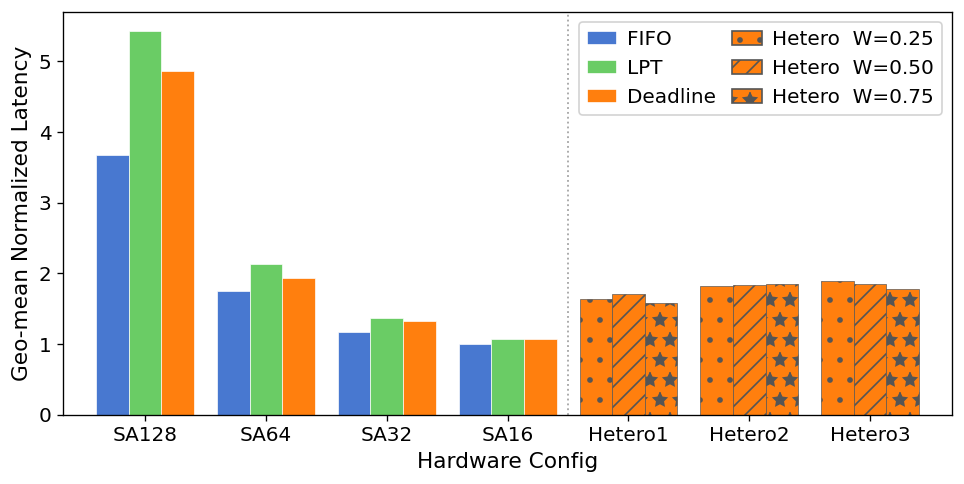

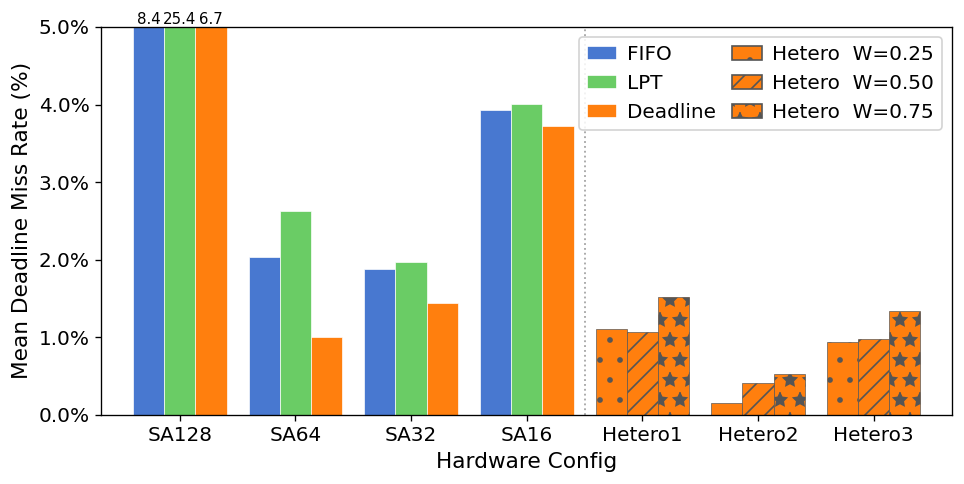

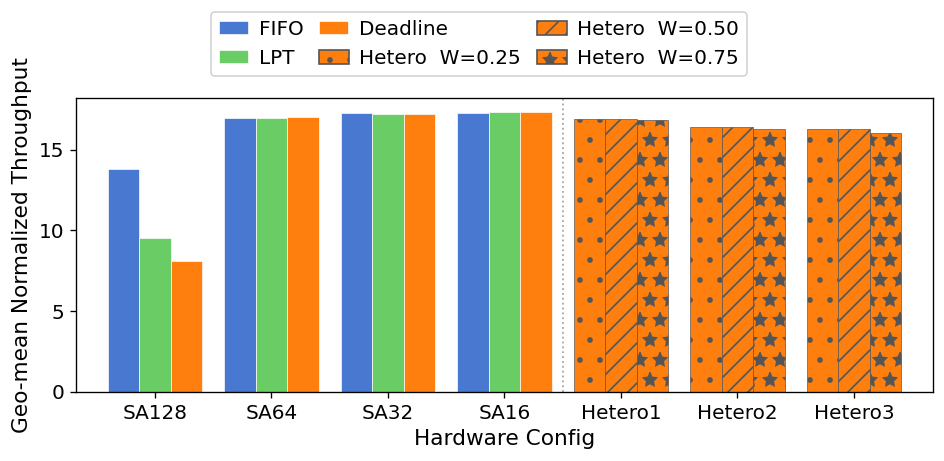

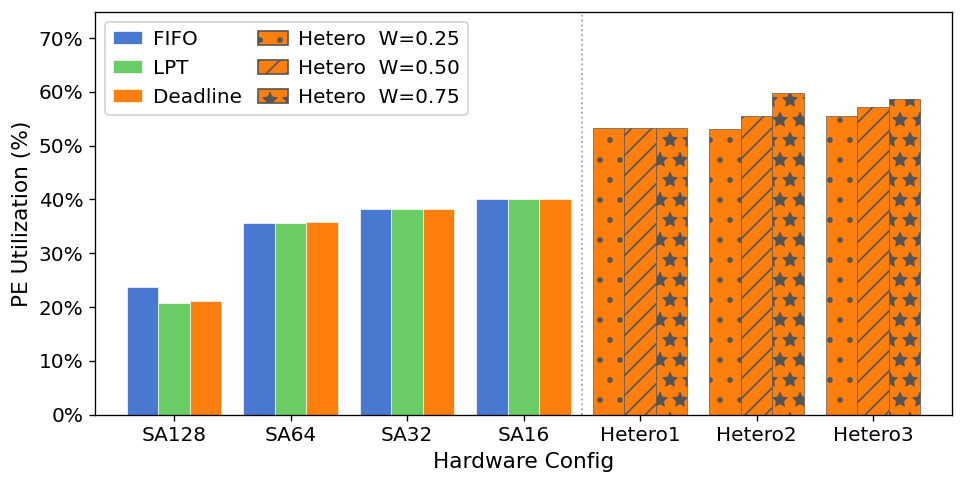

In [92]:
plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.labelsize':   13,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  10,
    'axes.titlepad':     6,
    'figure.dpi':       120,
})

x_all   = np.arange(len(ALL_HW_ORDER))
w       = 0.27
offsets = np.array([-1, 0, 1]) * w

def _getv(piv, hw, lp):
    try:
        v = float(piv.at[hw, lp])
        return None if np.isnan(v) else v
    except (KeyError, ValueError):
        return None

def bar_group_v2(ax, homo_piv, hetero_piv, fmt=None, log_scale=False,
                 mono128_only_labels=False, label_ymax=None, labels_above_axis=False):
    all_vals = []
    for hw in ALL_HW_ORDER:
        is_homo = hw in HOMO_HW_ORDER
        piv = homo_piv if is_homo else hetero_piv
        lps = LP_KEYS if is_homo else HETERO_LP_KEYS
        for lp in lps:
            v = _getv(piv, hw, lp)
            if v is not None:
                all_vals.append(v)
    vmax = max(all_vals) if all_vals else 1.0

    for j, hw in enumerate(ALL_HW_ORDER):
        is_homo = hw in HOMO_HW_ORDER
        lps = LP_KEYS if is_homo else HETERO_LP_KEYS
        piv = homo_piv if is_homo else hetero_piv
        for i, lp in enumerate(lps):
            v = _getv(piv, hw, lp)
            if v is None:
                continue
            xpos = x_all[j] + offsets[i]
            if is_homo:
                ax.bar(xpos, v, w, color=LP_COLORS[lp],
                       edgecolor='white', linewidth=0.4)
            else:
                ax.bar(xpos, v, w, color=HETERO_COLOR,
                       hatch=HETERO_HATCHES[i], edgecolor=HETERO_EDGE, linewidth=0.4)
            if fmt and (not mono128_only_labels or hw == 'mono128'):
                label_ref = label_ymax if label_ymax is not None else vmax
                if log_scale:
                    y = v + v * 0.04
                else:
                    yoff = label_ref * 0.025
                    if labels_above_axis and label_ymax is not None:
                        y = label_ref
                    else:
                        y = min(v + yoff, label_ref * 0.96) if label_ymax is not None else v + yoff
                ax.text(xpos, y, fmt % v,
                        ha='center', va='bottom', fontsize=9, clip_on=not labels_above_axis)

    ax.axvline(len(HOMO_HW_ORDER) - 0.5, color='grey',
               linestyle=':', linewidth=1.1, alpha=0.7)
    ax.set_xticks(x_all)
    ax.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.margins(x=0.04)

    legend_els = [
        Patch(facecolor=LP_COLORS['fifo_greedy'],    edgecolor='white', label='FIFO'),
        Patch(facecolor=LP_COLORS['lpt_greedy'],      edgecolor='white', label='LPT'),
        Patch(facecolor=LP_COLORS['deadline_greedy'], edgecolor='white', label='Deadline'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[0],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.25'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[1],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.50'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[2],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.75'),
    ]
    ax.legend(handles=legend_els, ncol=2, framealpha=0.85,
              handlelength=1.5, handletextpad=0.5, columnspacing=0.8, fontsize=12)
    return legend_els


# ── xrbench_5_06 single-tenant profiling baselines (SA128, TIME_REPORT us) ───
PROFILE_BASE = Path('outputs/xrbench_5_06')
_baseline_us = {}
for _m in LATENCY_MODELS + THROUGHPUT_MODELS:
    _tf = next((PROFILE_BASE / _m / 'sa128').glob('*/TIME_REPORT.csv'))
    _df = pd.read_csv(_tf)
    _df.columns = _df.columns.str.strip()
    _baseline_us[_m] = float(_df['Time (us)'].sum())

# Per-model mean response time on comp64x16 (SA16) under FIFO+Greedy — new normalisation baseline
_sa16_fifo_us = {
    m: (trace[(trace['hardware'] == 'comp64x16') & (trace['lp_key'] == 'fifo_greedy')
              & (trace['mode'] == 'latency') & (trace['model'] == m)]['response_cycles'].mean()
        / CPS * 1e6)
    for m in LATENCY_MODELS
}

# ── geo-mean normalized pivot for ratio metrics (latency, throughput) ─────────
def _geo_norm_piv(hw_order, lp_list, model_order, metric_fn, base_fn):
    """For each (hw, lp) bar: geo-mean of (metric / baseline) across models."""
    records = []
    for hw in hw_order:
        for lp in lp_list:
            sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp)]
            norms = []
            for model in model_order:
                val = metric_fn(sub[sub['model'] == model], model)
                if val is None:
                    continue
                base = base_fn(model)
                norms.append(max(val / base, 1e-9))
            geo = float(np.exp(np.mean(np.log(norms)))) if norms else np.nan
            records.append({'hardware': hw, 'lp_key': lp, 'value': geo})
    return (pd.DataFrame(records)
              .pivot(index='hardware', columns='lp_key', values='value')
              .reindex(hw_order))

# ── arithmetic-mean pivot for miss rate (avoids log(0) for 0% models) ─────────
def _arith_piv(hw_order, lp_list, model_order, metric_fn):
    """For each (hw, lp) bar: arithmetic mean of metric across models."""
    records = []
    for hw in hw_order:
        for lp in lp_list:
            sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp)]
            vals = []
            for model in model_order:
                val = metric_fn(sub[sub['model'] == model], model)
                if val is not None:
                    vals.append(float(val))
            mean = float(np.mean(vals)) if vals else np.nan
            records.append({'hardware': hw, 'lp_key': lp, 'value': mean})
    return (pd.DataFrame(records)
              .pivot(index='hardware', columns='lp_key', values='value')
              .reindex(hw_order))

# Latency: geo-mean of (mean response us / SA128 single-tenant baseline us)
def _lat_val(sub, model):
    s = sub[sub['mode'] == 'latency']
    return None if s.empty else s['response_cycles'].mean() / CPS * 1e6

geo_lat_homo   = _geo_norm_piv(HOMO_HW_ORDER,  LP_KEYS,        LATENCY_MODELS,   _lat_val, lambda m: _sa16_fifo_us[m])
geo_lat_hetero = _geo_norm_piv(HETERO_HW_ORDER, HETERO_LP_KEYS, LATENCY_MODELS,   _lat_val, lambda m: _sa16_fifo_us[m])

# Miss rate: arithmetic mean of per-model miss rate (%) across models
# (arithmetic mean preserves 0% models correctly; geo-mean would be dominated by the zero floor)
def _miss_val(sub, model):
    s = sub[sub['mode'] == 'latency']
    return None if s.empty else s['deadline_miss'].mean() * 100

arith_miss_homo   = _arith_piv(HOMO_HW_ORDER,  LP_KEYS,        LATENCY_MODELS, _miss_val)
arith_miss_hetero = _arith_piv(HETERO_HW_ORDER, HETERO_LP_KEYS, LATENCY_MODELS, _miss_val)

# Throughput: geo-mean of (completed rps / SA128 single-tenant capacity)
def _tp_val(sub, model):
    s = sub[(sub['mode'] == 'throughput') & (sub['deadline_miss'] == 0)]
    return None if s.empty else len(s) / DURATION_S

geo_tp_homo   = _geo_norm_piv(HOMO_HW_ORDER,  LP_KEYS,        THROUGHPUT_MODELS, _tp_val, lambda m: 1e6 / _baseline_us[m])
geo_tp_hetero = _geo_norm_piv(HETERO_HW_ORDER, HETERO_LP_KEYS, THROUGHPUT_MODELS, _tp_val, lambda m: 1e6 / _baseline_us[m])

print("SA128 single-tenant baselines (us):", {m: f'{v:,.0f}' for m, v in _baseline_us.items()})

bar_value_table = (
    pd.concat({
        'latency_norm_x_sa128': pd.concat([geo_lat_homo, geo_lat_hetero]),
        'deadline_miss_pct': pd.concat([arith_miss_homo, arith_miss_hetero]),
        'throughput_norm_x_sa128': pd.concat([geo_tp_homo, geo_tp_hetero]),
    }, axis=1)
    .stack(level=1, future_stack=True)
    .rename_axis(index=['hardware', 'policy'])
    .reset_index()
)
bar_value_table = bar_value_table.dropna(subset=[
    'latency_norm_x_sa128',
    'deadline_miss_pct',
    'throughput_norm_x_sa128',
], how='all')
bar_value_table['hardware'] = bar_value_table['hardware'].map(HW_LABELS)
bar_value_table['policy'] = bar_value_table['policy'].map({**LP_LABELS, **HETERO_LP_LABELS})
print("\nBar plot values:")
print(bar_value_table.round({
    'latency_norm_x_sa128': 3,
    'deadline_miss_pct': 2,
    'throughput_norm_x_sa128': 2,
}).to_string(index=False))

# Fig 1 -- Geo-mean Normalized Latency (vs SA128 single-tenant)
fig1, ax1 = plt.subplots(figsize=(8, 4))
bar_group_v2(ax1, geo_lat_homo, geo_lat_hetero, log_scale=False)
ax1.set_ylabel('Geo-mean Normalized Latency')
ax1.set_xlabel('Hardware Config')
# ax1.set_title('Normalized Response Latency — Latency-Sensitive Models')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
plt.tight_layout(pad=0.5)
plt.savefig('outputs/latency.pdf', bbox_inches='tight')
plt.show()


# Fig 2 -- Arithmetic-mean Deadline Miss Rate across latency models
fig2, ax2 = plt.subplots(figsize=(8, 4))
bar_group_v2(ax2, arith_miss_homo, arith_miss_hetero, fmt='%.1f',
             mono128_only_labels=True, label_ymax=5.0, labels_above_axis=True)
ax2.set_ylabel('Mean Deadline Miss Rate (%)')
ax2.set_xlabel('Hardware Config')
# ax2.set_title('Deadline Miss Rate — Latency-Sensitive Models')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_ylim(0, 5)
plt.tight_layout(pad=0.5)
plt.savefig('outputs/miss_rate.pdf', bbox_inches='tight')
plt.show()


# Fig 3 -- Geo-mean Normalized Throughput (both throughput models combined)
fig3, ax3 = plt.subplots(figsize=(8, 4))
legend_els = bar_group_v2(ax3, geo_tp_homo, geo_tp_hetero)
ax3.legend(handles=legend_els, ncol=3, loc='upper center',
           bbox_to_anchor=(0.47, 1.3), borderaxespad=0.1, framealpha=0.85,
           handlelength=1.5, handletextpad=0.5, columnspacing=0.8, fontsize=12)
ax3.set_ylabel('Geo-mean Normalized Throughput')
ax3.set_xlabel('Hardware Config')
# ax3.set_title('Normalized Throughput — Best-Effort Models')
plt.tight_layout(pad=0.5)
plt.savefig('outputs/throughput.pdf', bbox_inches='tight')
plt.show()


# Fig 4 -- PE Utilization
util_pct   = util_pivot   * 100
util_pct_h = util_pivot_h * 100

all_util  = pd.concat([util_pct, util_pct_h])
ylim_util = max(50.0, float(all_util.max().max()) * 1.25)

fig4, ax4 = plt.subplots(figsize=(8, 4))
bar_group_v2(ax4, util_pct, util_pct_h)
ax4.set_ylabel('PE Utilization (%)')
ax4.set_xlabel('Hardware Config')
# ax4.set_title('PE Utilization -- MappingEff x ComputeUtil x Temporal Occupancy')
ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
ax4.set_ylim(0, ylim_util)
plt.tight_layout(pad=0.5)
plt.savefig('outputs/utilization.pdf', bbox_inches='tight')
plt.show()


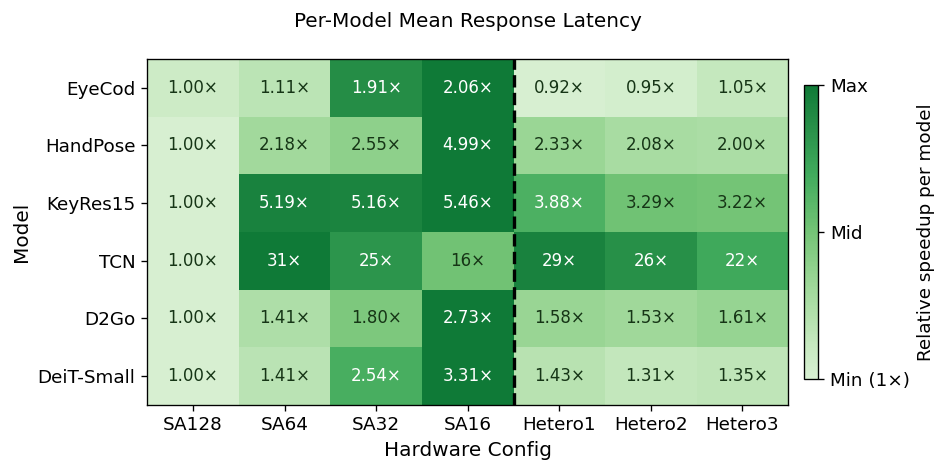

In [93]:
# ── Fig 5 : Per-model latency heatmap (speedup over mono128) ──────────────────
# Policy: deadline_task_aware + deadline_fold (homo), + hetero_W50 (hetero).
# Speedup = mono128_mean_response / hw_mean_response  (higher → lower latency → more green).
# Color is per-row normalized so each model uses the full green range independently
# (avoids mobilellm_125m's 400x speedup washing out the latency model differences).
# Cell annotations show the actual speedup value.

from matplotlib.colors import LinearSegmentedColormap

HEATMAP_LP = {
    'mono128':   'deadline_deadline_fold',
    'comp4x64':  'deadline_deadline_fold',
    'comp16x32': 'deadline_deadline_fold',
    'comp64x16': 'deadline_deadline_fold',
    'hetero1':   'deadline_hetero_W50',
    'hetero2':   'deadline_hetero_W50',
    'hetero3':   'deadline_hetero_W50',
}

HM_MODEL_ORDER = ['eyecod', 'hand_pose', 'key_res15', 'tcn', 'd2go', 'deit_small',]
HM_MODEL_LABELS = {
    'eyecod':          'EyeCod',
    'hand_pose':       'HandPose',
    'key_res15':       'KeyRes15',
    'tcn':             'TCN',
    'd2go':            'D2Go',
    'deit_small':      'DeiT-Small',
}

# Per-(hw, model) mean response time (ms), all completed requests
mean_resp_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)].copy()
    sub['response_ms'] = sub['response_cycles'] / CPS * 1000
    mean_resp_cols[hw] = sub.groupby('model')['response_ms'].mean()

resp_df = pd.DataFrame(mean_resp_cols).reindex(index=HM_MODEL_ORDER, columns=ALL_HW_ORDER)

# Actual speedup values (for annotations)
mono_vals   = resp_df['mono128'].values.reshape(-1, 1)
speedup_arr = mono_vals / resp_df.values          # shape: (n_models, n_hw)

# Per-row normalize to [0, 1] so each model uses the full green range
row_min = speedup_arr.min(axis=1, keepdims=True)
row_max = speedup_arr.max(axis=1, keepdims=True)
data_norm = (speedup_arr - row_min) / np.where(row_max > row_min, row_max - row_min, 1.0)

# Clipped Greens: sample [0.18, 0.82] to avoid near-white and near-black extremes
green_mid = LinearSegmentedColormap.from_list(
    'green_mid', plt.cm.Greens(np.linspace(0.18, 0.82, 256))
)

fig5, ax5 = plt.subplots(figsize=(8, 4))
im = ax5.imshow(data_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)

# Annotate every cell with actual speedup; flip text colour at midpoint
for i in range(len(HM_MODEL_ORDER)):
    for j in range(len(ALL_HW_ORDER)):
        v_actual = speedup_arr[i, j]
        v_norm   = data_norm[i, j]
        txt_color = 'white' if v_norm > 0.55 else '#163516'
        label = f'{v_actual:.0f}×' if v_actual >= 10 else f'{v_actual:.2f}×'
        ax5.text(j, i, label, ha='center', va='center',
                 fontsize=10, color=txt_color)

# Dashed separator: latency models / throughput models
n_lat = len(LATENCY_MODELS)
# ax5.axhline(n_lat - 0.5, color='black', linewidth=2, linestyle='--')
# Solid separator: homogeneous / heterogeneous configs
ax5.axvline(len(HOMO_HW_ORDER) - 0.5, color='black', linewidth=2, linestyle='--')

ax5.set_xticks(range(len(ALL_HW_ORDER)))
ax5.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=11)
ax5.set_yticks(range(len(HM_MODEL_ORDER)))
ax5.set_yticklabels([HM_MODEL_LABELS[m] for m in HM_MODEL_ORDER], fontsize=11)

cbar = plt.colorbar(im, ax=ax5, shrink=0.85, pad=0.02)
cbar.set_label('Relative speedup per model', fontsize=11) #   (per-row normalized)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(['Min (1×)', 'Mid', 'Max'])

ax5.set_title(
    'Per-Model Mean Response Latency\n',
    # 'Colour normalized per row  |  Policy: deadline_task_aware + deadline_fold  |  † = throughput / best-effort', — Speedup over mono128 (1×SA128)
    fontsize=12, # pad=2,
)
ax5.set_xlabel('Hardware Config', fontsize=12)
ax5.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/latency_heatmap.pdf', bbox_inches='tight')
plt.show()


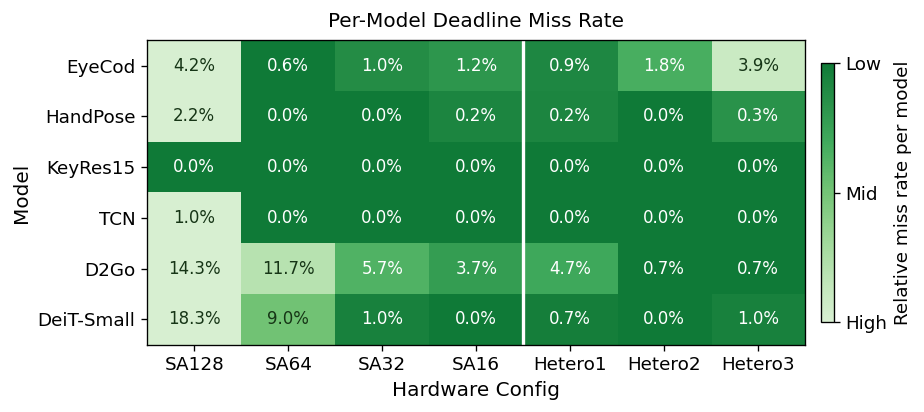

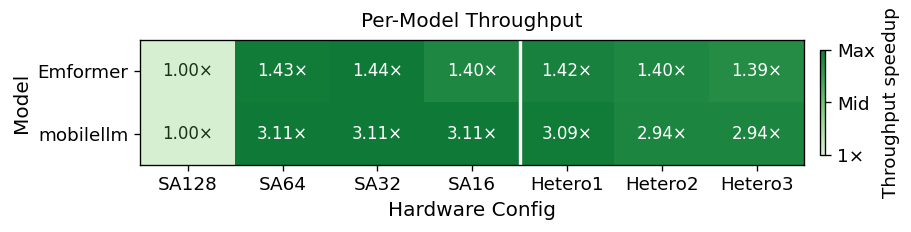

In [94]:
# ── Fig 6 : Deadline miss rate heatmap (latency models) ───────────────────────
# ── Fig 7 : Throughput heatmap (throughput / best-effort models) ───────────────
# Same policy selection as Fig 5.
# Miss rate heatmap : lower miss rate → darker green  (invert normalization per row).
# Throughput heatmap: speedup over mono128 (SA128 = 1×), higher → darker green.

from matplotlib.colors import LinearSegmentedColormap

HEATMAP_LP = {
    'mono128':   'deadline_deadline_fold',
    'comp4x64':  'deadline_deadline_fold',
    'comp16x32': 'deadline_deadline_fold',
    'comp64x16': 'deadline_deadline_fold',
    'hetero1':   'deadline_hetero_W50',
    'hetero2':   'deadline_hetero_W50',
    'hetero3':   'deadline_hetero_W50',
}

LAT_MODEL_ORDER = ['eyecod', 'hand_pose', 'key_res15', 'tcn', 'd2go', 'deit_small']
LAT_MODEL_LABELS = {
    'eyecod':     'EyeCod',     'hand_pose':  'HandPose',
    'key_res15':  'KeyRes15',   'tcn':        'TCN',
    'd2go':       'D2Go',       'deit_small': 'DeiT-Small',
}

TP_MODEL_ORDER  = ['emformer', 'mobilellm_125m']
TP_MODEL_LABELS = {'emformer': 'Emformer', 'mobilellm_125m': 'mobilellm'}

green_mid = LinearSegmentedColormap.from_list(
    'green_mid', plt.cm.Greens(np.linspace(0.18, 0.82, 256))
)

def _annotate(ax, data_norm, data_actual, model_order, fmt_fn, threshold=0.55):
    for i in range(len(model_order)):
        for j in range(len(ALL_HW_ORDER)):
            v_norm   = data_norm[i, j]
            v_actual = data_actual[i, j]
            txt_color = 'white' if v_norm > threshold else '#163516'
            ax.text(j, i, fmt_fn(v_actual), ha='center', va='center',
                    fontsize=10, color=txt_color)

def _axis_labels(ax, model_order, model_labels):
    ax.set_xticks(range(len(ALL_HW_ORDER)))
    ax.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=11)
    ax.set_yticks(range(len(model_order)))
    ax.set_yticklabels([model_labels[m] for m in model_order], fontsize=11)
    ax.axvline(len(HOMO_HW_ORDER) - 0.5, color='white', linewidth=2)

def _cbar(fig, ax, im, label):
    cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(label, fontsize=11)
    cb.set_ticks([0.0, 0.5, 1.0])
    return cb

# ── Fig 6 : Miss rate ─────────────────────────────────────────────────────────
miss_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)
                & (trace['mode'] == 'latency')]
    miss_cols[hw] = sub.groupby('model')['deadline_miss'].mean() * 100

miss_df  = pd.DataFrame(miss_cols).reindex(index=LAT_MODEL_ORDER, columns=ALL_HW_ORDER)
miss_arr = miss_df.values.astype(float)

# Invert: lower miss rate → higher normalised value → darker green
row_min_m = miss_arr.min(axis=1, keepdims=True)
row_max_m = miss_arr.max(axis=1, keepdims=True)
denom_m   = np.where(row_max_m > row_min_m, row_max_m - row_min_m, 1.0)
miss_norm = 1.0 - (miss_arr - row_min_m) / denom_m

fig6, ax6 = plt.subplots(figsize=(8, 3.5))
im6 = ax6.imshow(miss_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)
_annotate(ax6, miss_norm, miss_arr, LAT_MODEL_ORDER,
          fmt_fn=lambda v: f'{v:.1f}%')
_axis_labels(ax6, LAT_MODEL_ORDER, LAT_MODEL_LABELS)

cb6 = _cbar(fig6, ax6, im6, 'Relative miss rate per model') #  (per-row normalized)
cb6.set_ticklabels(['High', 'Mid', 'Low'])

ax6.set_title(
    'Per-Model Deadline Miss Rate',
    # 'Darker green = fewer misses  |  Policy: deadline_task_aware + deadline_fold',e — Latency-Sensitive Models\n
    fontsize=12, pad=8,
)
ax6.set_xlabel('Hardware Config', fontsize=12)
ax6.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/miss_rate_heatmap.pdf', bbox_inches='tight')
plt.show()

# ── Fig 7 : Throughput (speedup over mono128) ─────────────────────────────────
tp_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)
                & (trace['mode'] == 'throughput')]
    tp_cols[hw] = sub.groupby('model').size() / DURATION_S

tp_df   = pd.DataFrame(tp_cols).reindex(index=TP_MODEL_ORDER, columns=ALL_HW_ORDER)
mono_tp = tp_df['mono128'].values.reshape(-1, 1)
tp_arr  = (tp_df.values / mono_tp).astype(float)   # mono128 col → 1.00×

# Per-row normalize for color (higher speedup → darker green)
row_min_t = tp_arr.min(axis=1, keepdims=True)
row_max_t = tp_arr.max(axis=1, keepdims=True)
denom_t   = np.where(row_max_t > row_min_t, row_max_t - row_min_t, 1.0)
tp_norm   = (tp_arr - row_min_t) / denom_t

fig7, ax7 = plt.subplots(figsize=(8, 2))
im7 = ax7.imshow(tp_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)
_annotate(ax7, tp_norm, tp_arr, TP_MODEL_ORDER,
          fmt_fn=lambda v: f'{v:.2f}×')
_axis_labels(ax7, TP_MODEL_ORDER, TP_MODEL_LABELS)

cb7 = _cbar(fig7, ax7, im7, 'Throughput speedup') # over mono128  (per-row normalized)')
cb7.set_ticklabels(['1×', 'Mid', 'Max'])

ax7.set_title(
    'Per-Model Throughput',
    # 'Speedup over mono128 (1×SA128)  |  Policy: deadline_task_aware + deadline_fold', — Best-Effort / Throughput Models\n
    fontsize=12, pad=8,
)
ax7.set_xlabel('Hardware Config', fontsize=12)
ax7.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/throughput_heatmap.pdf', bbox_inches='tight')
plt.show()


Deadline miss rate (%) — FIFO + Greedy:
Hardware            SA128       SA64       SA32       SA16
Miss rate %         16.3%       2.6%       2.1%       3.4%


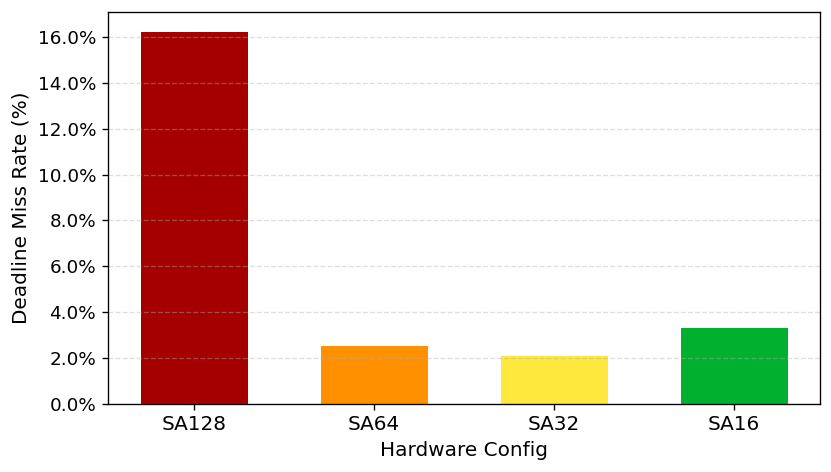


Per-model deadline miss rate (%) — mono128, FIFO + Greedy:
  EyeCod        36.0%
  HandPose      13.5%
  KeyRes15      0.0%
  TCN           0.0%
  D2Go          0.3%
  DeiT-Small    0.3%


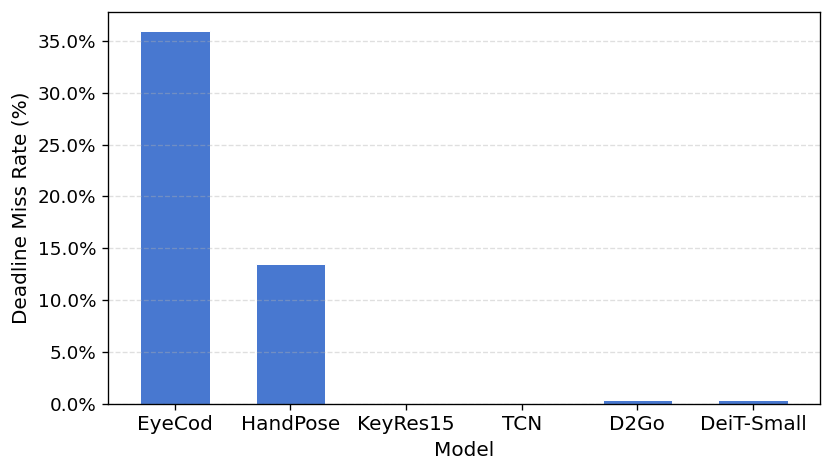

In [95]:
# ── Baseline miss rate: FIFO+Greedy across homogeneous hardware configs ─────────────
BASELINE_HW_4 = ['mono128', 'comp4x64', 'comp16x32', 'comp64x16']
BASELINE_LP   = 'fifo_greedy'
BASELINE_COLORS = ["#a40000", "#ff9100", "#ffe83d", "#02b030"]

# ── Fig A: per-hw arithmetic-mean miss rate ──────────────────────────────────
hw_miss = {}
for hw in BASELINE_HW_4:
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == BASELINE_LP)
                & (trace['mode'] == 'latency')]
    hw_miss[hw] = sub['deadline_miss'].mean() * 100 if not sub.empty else float('nan')

print('Deadline miss rate (%) — FIFO + Greedy:')
print(f"{'Hardware':<14}", end='')
for hw in BASELINE_HW_4:
    print(f"  {HW_LABELS[hw]:>9}", end='')
print()
print(f"{'Miss rate %':<14}", end='')
for hw in BASELINE_HW_4:
    print(f"  {hw_miss[hw]:>8.1f}%", end='')
print()

fig_a, ax_a = plt.subplots(figsize=(7, 4))
x = np.arange(len(BASELINE_HW_4))
bars_a = ax_a.bar(x, [hw_miss[h] for h in BASELINE_HW_4],
                  color=BASELINE_COLORS, edgecolor='white', linewidth=0.6, width=0.6)

ax_a.set_xticks(x)
ax_a.set_xticklabels([HW_LABELS[h] for h in BASELINE_HW_4], fontsize=12)
ax_a.set_ylabel('Deadline Miss Rate (%)', fontsize=12)
ax_a.set_xlabel('Hardware Config', fontsize=12)
# ax_a.set_title('Deadline Miss Rate — FIFO + Greedy Allocation\n'
            #    '(Arithmetic mean across latency-sensitive models)', fontsize=13)
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_a.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(pad=0.8)
plt.savefig('outputs/baseline_miss_rate.pdf', bbox_inches='tight')
plt.show()

# ── Fig B: per-model miss rate for mono128 under FIFO+Greedy ───────────────
sub_mono = trace[(trace['hardware'] == 'mono128') & (trace['lp_key'] == 'fifo_greedy')
                 & (trace['mode'] == 'latency')]
per_model_miss = (
    sub_mono.groupby('model')['deadline_miss'].mean() * 100
).reindex(LAT_MODEL_ORDER)

print('\nPer-model deadline miss rate (%) — mono128, FIFO + Greedy:')
for m in LAT_MODEL_ORDER:
    print(f"  {LAT_MODEL_LABELS[m]:<12}  {per_model_miss[m]:.1f}%")

fig_b, ax_b = plt.subplots(figsize=(7, 4))
bars_b = ax_b.bar(range(len(LAT_MODEL_ORDER)), per_model_miss.values,
                  color='#4878d0', edgecolor='white', linewidth=0.6, width=0.6)

ax_b.set_xticks(range(len(LAT_MODEL_ORDER)))
ax_b.set_xticklabels([LAT_MODEL_LABELS[m] for m in LAT_MODEL_ORDER], fontsize=12)
ax_b.set_ylabel('Deadline Miss Rate (%)', fontsize=12)
ax_b.set_xlabel('Model', fontsize=12)
# ax_b.set_title('Per-Model Deadline Miss Rate — mono128, FIFO + Greedy', fontsize=13)
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_b.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(pad=0.8)
plt.savefig('outputs/per_model_miss_mono128.pdf', bbox_inches='tight')
plt.show()
